In [28]:
from afrip_pipeline_classes import *
import joblib

fraud_pipeline = joblib.load("afrip_fraud_pipeline.pkl")
print(type(fraud_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [29]:
import pandas as pd

train_df = pd.read_csv(
    r"M:\data_set\fraudTrain.csv"
)

print(train_df.shape)
print(train_df.columns.tolist())

(1296675, 23)
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


# ==========================================
# 2. Keep only columns needed for Risk
# ==========================================

In [ ]:
print(train_df["trans_date_trans_time"].unique())
print(train_df["trans_date_trans_time"].value_counts())

['2019-01-01 00:00:18' '2019-01-01 00:00:44' '2019-01-01 00:00:51' ...
 '2020-06-21 12:12:32' '2020-06-21 12:13:36' '2020-06-21 12:13:37']
trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2019-06-03 01:08:00    3
2019-08-16 15:08:51    3
                      ..
2019-01-01 00:11:14    1
2019-01-01 00:12:34    1
2019-01-01 00:13:08    1
2019-01-01 00:14:37    1
2019-01-01 00:05:08    1
Name: count, Length: 1274791, dtype: int64


In [ ]:
print(train_df["category"].unique())
print(train_df["category"].value_counts())

['misc_net' 'grocery_pos' 'entertainment' 'gas_transport' 'misc_pos'
 'grocery_net' 'shopping_net' 'shopping_pos' 'food_dining' 'personal_care'
 'health_fitness' 'travel' 'kids_pets' 'home']
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64


In [ ]:
# Amount distribution

print(train_df["amt"].describe())

print("\nPercentiles:")

print(
    train_df["amt"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

Percentiles:
0.25      9.6500
0.50     47.5200
0.75     83.1400
0.90    136.6700
0.95    196.3100
0.99    545.9926
Name: amt, dtype: float64


Baseline Fraud Rate

In [ ]:
def compute_baseline_rate(df, target_col="is_fraud"):
    baseline_rate = df[target_col].mean()
    return baseline_rate

baseline_rate = compute_baseline_rate(train_df)

print("Baseline Fraud Rate %:", baseline_rate * 100)

print("\nClass Distribution:")
print(train_df["is_fraud"].value_counts())

Baseline Fraud Rate %: 0.5788651743883394

Class Distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


Amount Risk. 

In [ ]:
def compute_amount_bins(
    df,
    amt_col="amt",
    target_col="is_fraud",
    baseline_rate=None
):

    bins = [
        0,
        47.50,
        83.05,
        136.44,
        196.07,
        548.6261,
        np.inf
    ]

    labels = [
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High",
        "Extreme"
    ]

    df = df.copy()

    df["amount_bin"] = pd.cut(
        df[amt_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    summary = df.groupby(
        "amount_bin",
        observed=True
    ).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )

    summary["fraud_rate"] = (
        summary["fraud_count"] /
        summary["count"]
    )

    summary["risk_ratio"] = (
        summary["fraud_rate"] /
        baseline_rate
    )

    return summary


amount_summary = compute_amount_bins(
    train_df,
    baseline_rate=baseline_rate
)

display(amount_summary)

,count,fraud_count,fraud_rate,risk_ratio
amount_bin,,,,
Very Low,648228,1565,0.002414,0.417070
Low,323735,81,0.000250,0.043223
Medium,194596,136,0.000699,0.120733
High,65084,19,0.000292,0.050432
Very High,52169,2105,0.040350,6.970472
Extreme,12863,3600,0.279873,48.348478


In [ ]:
import matplotlib.pyplot as plt 

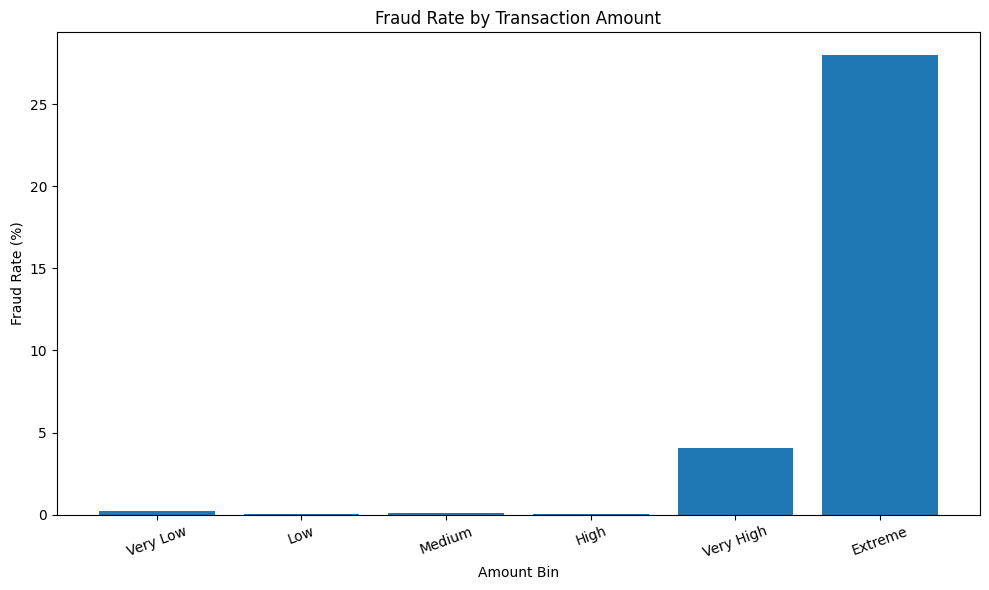

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    amount_summary.index,
    amount_summary["fraud_rate"] * 100
)

plt.xlabel("Amount Bin")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Amount")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

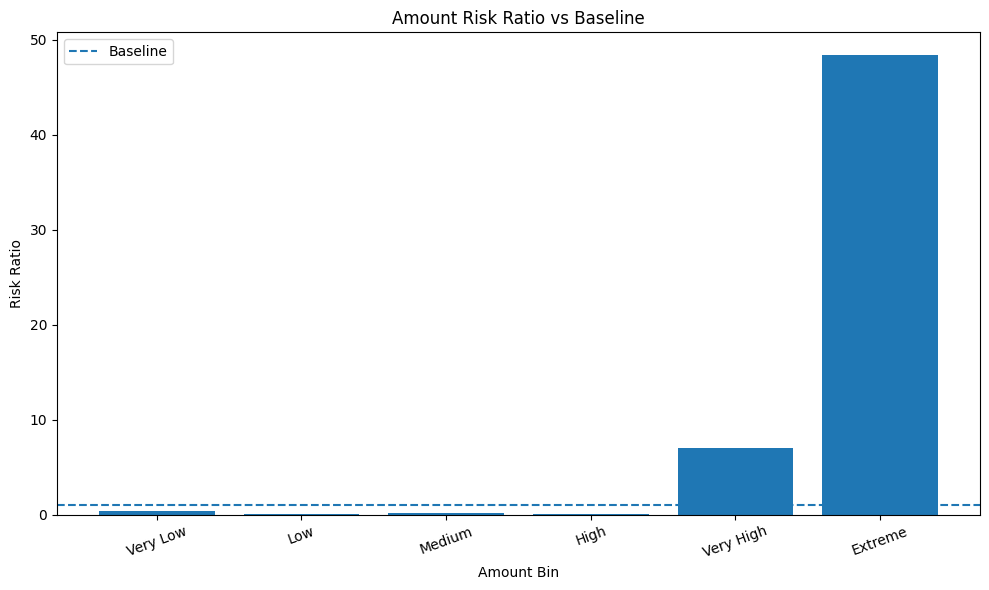

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    amount_summary.index,
    amount_summary["risk_ratio"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Amount Bin")
plt.ylabel("Risk Ratio")
plt.title("Amount Risk Ratio vs Baseline")

plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def compute_amount_bins_v2(
    df,
    amt_col="amt",
    target_col="is_fraud",
    baseline_rate=None
):

    bins = [
        0,
        47.50,
        196.07,
        548.6261,
        np.inf
    ]

    labels = [
        "Very Low",
        "Normal",
        "Very High",
        "Extreme"
    ]

    df = df.copy()

    df["amount_bin"] = pd.cut(
        df[amt_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    summary = df.groupby(
        "amount_bin",
        observed=True
    ).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )

    summary["fraud_rate"] = (
        summary["fraud_count"] /
        summary["count"]
    )

    summary["risk_ratio"] = (
        summary["fraud_rate"] /
        baseline_rate
    )

    return summary


amount_summary_v2 = compute_amount_bins_v2(
   train_df,
    baseline_rate=baseline_rate
)

display(amount_summary_v2)

,count,fraud_count,fraud_rate,risk_ratio
amount_bin,,,,
Very Low,648228,1565,0.002414,0.417070
Normal,583415,236,0.000405,0.069881
Very High,52169,2105,0.040350,6.970472
Extreme,12863,3600,0.279873,48.348478


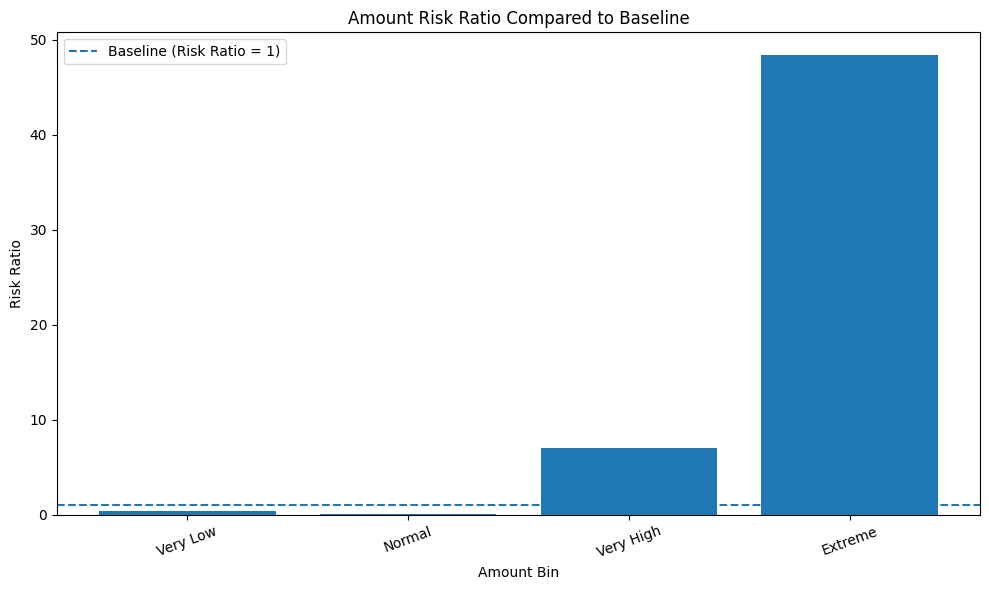

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    amount_summary_v2.index,
    amount_summary_v2["risk_ratio"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline (Risk Ratio = 1)"
)

plt.xlabel("Amount Bin")
plt.ylabel("Risk Ratio")
plt.title("Amount Risk Ratio Compared to Baseline")

plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

Baseline Fraud Rate
                  (0.5789%  →  risk_ratio = 1.0)
                            |
                            |
        ┌───────────────────┴───────────────────┐
        |                                        |
  Lower Risk Zone                         Higher Risk Zone
   (risk_ratio < 1)                        (risk_ratio > 1)
        |                                        |
   ┌────┴────┐                            ┌───────┴───────┐
   |         |                            |               |
 Normal   Very Low                    Very High         Extreme
 ratio=   ratio=                      ratio=             ratio=
  0.07     0.42                        6.96              48.12


Time Risk

In [31]:
# ==========================================
# 1. Time Feature Engineering
# ==========================================

train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

train_df["trans_hour"] = (
    train_df["trans_date_trans_time"].dt.hour
)

train_df["trans_day"] = (
    train_df["trans_date_trans_time"].dt.day
)

train_df["trans_month"] = (
    train_df["trans_date_trans_time"].dt.month
)

train_df["trans_dayofweek"] = (
    train_df["trans_date_trans_time"].dt.dayofweek
)




# ==========================================
# KEEP ONLY RISK COLUMNS
# ==========================================


In [32]:
RISK_COLS = [
    "amt",
    "category",
    "state",
    "merchant",
    "gender",
    "job",
    "trans_hour",
    "trans_day",
    "trans_month",
    "trans_dayofweek",
    "is_fraud"
]

train_df = train_df[RISK_COLS].copy()

print("Risk DataFrame shape:", train_df.shape)
print(train_df.columns.tolist())

Risk DataFrame shape: (1296675, 11)
['amt', 'category', 'state', 'merchant', 'gender', 'job', 'trans_hour', 'trans_day', 'trans_month', 'trans_dayofweek', 'is_fraud']


In [33]:
def compute_hour_summary(df, hour_col="trans_hour", target_col="is_fraud", baseline_rate=None):
    summary = df.groupby(hour_col, observed=True).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )
    summary["fraud_rate"] = summary["fraud_count"] / summary["count"]
    summary["risk_ratio"] = summary["fraud_rate"] / baseline_rate
    summary = summary.sort_index()

    return summary

hour_summary = compute_hour_summary(train_df, baseline_rate=baseline_rate)
display(hour_summary)

,count,fraud_count,fraud_rate,risk_ratio
trans_hour,,,,
0,42502,635,0.014940,2.580994
1,42869,658,0.015349,2.651582
2,42656,625,0.014652,2.531177
3,42769,609,0.014239,2.459862
4,41863,46,0.001099,0.189824
5,42171,60,0.001423,0.245788
6,42300,40,0.000946,0.163359
7,42203,56,0.001327,0.229228
8,42505,49,0.001153,0.199149


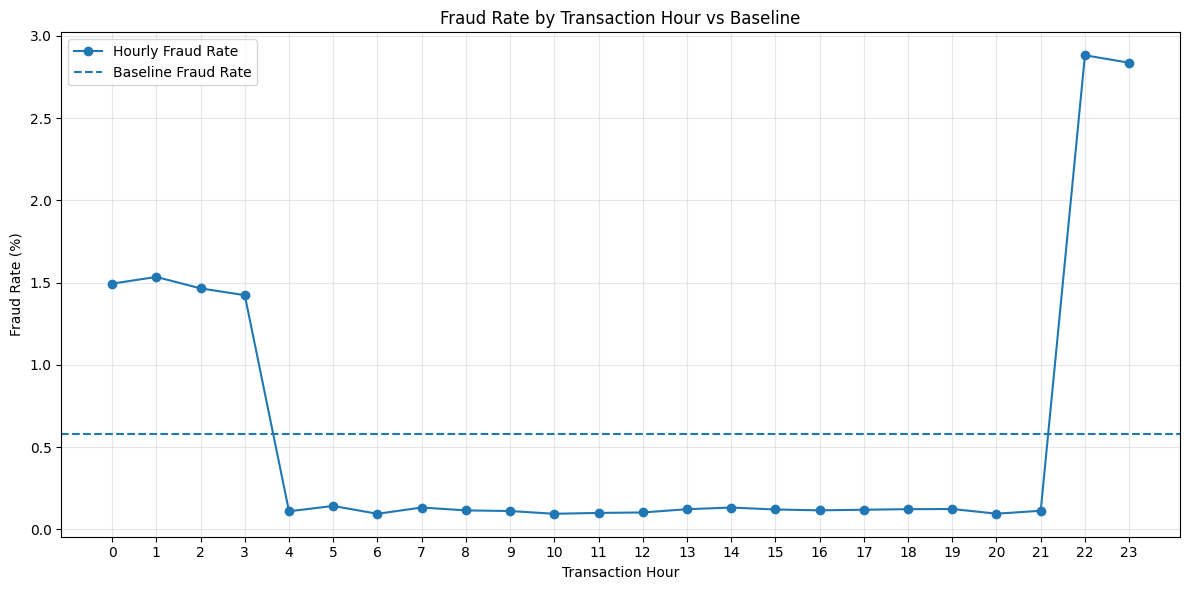

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(
    hour_summary.index,
    hour_summary["fraud_rate"] * 100,
    marker="o",
    label="Hourly Fraud Rate"
)

plt.axhline(
    y=baseline_rate * 100,
    linestyle="--",
    label="Baseline Fraud Rate"
)

plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Hour vs Baseline")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
def compute_time_bins(df, hour_col="trans_hour", target_col="is_fraud", baseline_rate=None):
    def map_hour_to_bin(hour):
        if hour in [22, 23]:
            return "Peak Risk"
        elif hour in [0, 1, 2, 3]:
            return "High Risk"
        else:
            return "Normal"

    df = df.copy()
    df["time_bin"] = df[hour_col].apply(map_hour_to_bin)

    summary = df.groupby("time_bin", observed=True).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )
    summary["fraud_rate"] = summary["fraud_count"] / summary["count"]
    summary["risk_ratio"] = summary["fraud_rate"] / baseline_rate

    return summary

time_summary = compute_time_bins(train_df, baseline_rate=baseline_rate)
display(time_summary)

,count,fraud_count,fraud_rate,risk_ratio
time_bin,,,,
High Risk,170796,2527,0.014795,2.555937
Normal,991793,1144,0.001153,0.199263
Peak Risk,134086,3835,0.028601,4.940882


category_name

In [ ]:
import pandas as pd

train_df = pd.read_csv(
    r"M:\data_set\fraudTrain.csv"
)

print(train_df.shape)
print(train_df.columns.tolist())

(1296675, 23)
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


# ==========================================
# 2. Keep only columns needed for Risk
# ==========================================

In [ ]:
print(train_df["trans_date_trans_time"].unique())
print(train_df["trans_date_trans_time"].value_counts())

['2019-01-01 00:00:18' '2019-01-01 00:00:44' '2019-01-01 00:00:51' ...
 '2020-06-21 12:12:32' '2020-06-21 12:13:36' '2020-06-21 12:13:37']
trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2019-06-03 01:08:00    3
2019-08-16 15:08:51    3
                      ..
2019-01-01 00:11:14    1
2019-01-01 00:12:34    1
2019-01-01 00:13:08    1
2019-01-01 00:14:37    1
2019-01-01 00:05:08    1
Name: count, Length: 1274791, dtype: int64


In [ ]:
print(train_df["category"].unique())
print(train_df["category"].value_counts())

['misc_net' 'grocery_pos' 'entertainment' 'gas_transport' 'misc_pos'
 'grocery_net' 'shopping_net' 'shopping_pos' 'food_dining' 'personal_care'
 'health_fitness' 'travel' 'kids_pets' 'home']
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64


In [ ]:
# Amount distribution

print(train_df["amt"].describe())

print("\nPercentiles:")

print(
    train_df["amt"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

Percentiles:
0.25      9.6500
0.50     47.5200
0.75     83.1400
0.90    136.6700
0.95    196.3100
0.99    545.9926
Name: amt, dtype: float64


Baseline Fraud Rate

In [ ]:
def compute_baseline_rate(df, target_col="is_fraud"):
    baseline_rate = df[target_col].mean()
    return baseline_rate

baseline_rate = compute_baseline_rate(train_df)

print("Baseline Fraud Rate %:", baseline_rate * 100)

print("\nClass Distribution:")
print(train_df["is_fraud"].value_counts())

Baseline Fraud Rate %: 0.5788651743883394

Class Distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


Amount Risk. 

In [ ]:
def compute_amount_bins(
    df,
    amt_col="amt",
    target_col="is_fraud",
    baseline_rate=None
):

    bins = [
        0,
        47.50,
        83.05,
        136.44,
        196.07,
        548.6261,
        np.inf
    ]

    labels = [
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High",
        "Extreme"
    ]

    df = df.copy()

    df["amount_bin"] = pd.cut(
        df[amt_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    summary = df.groupby(
        "amount_bin",
        observed=True
    ).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )

    summary["fraud_rate"] = (
        summary["fraud_count"] /
        summary["count"]
    )

    summary["risk_ratio"] = (
        summary["fraud_rate"] /
        baseline_rate
    )

    return summary


amount_summary = compute_amount_bins(
    train_df,
    baseline_rate=baseline_rate
)

display(amount_summary)

,count,fraud_count,fraud_rate,risk_ratio
amount_bin,,,,
Very Low,648228,1565,0.002414,0.417070
Low,323735,81,0.000250,0.043223
Medium,194596,136,0.000699,0.120733
High,65084,19,0.000292,0.050432
Very High,52169,2105,0.040350,6.970472
Extreme,12863,3600,0.279873,48.348478


In [ ]:
import matplotlib.pyplot as plt 

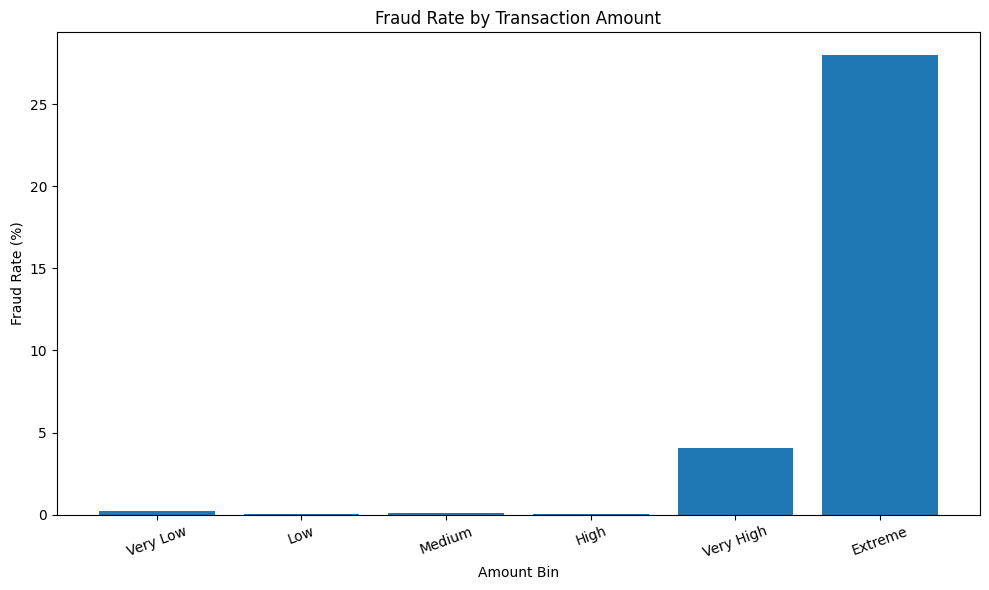

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    amount_summary.index,
    amount_summary["fraud_rate"] * 100
)

plt.xlabel("Amount Bin")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Amount")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

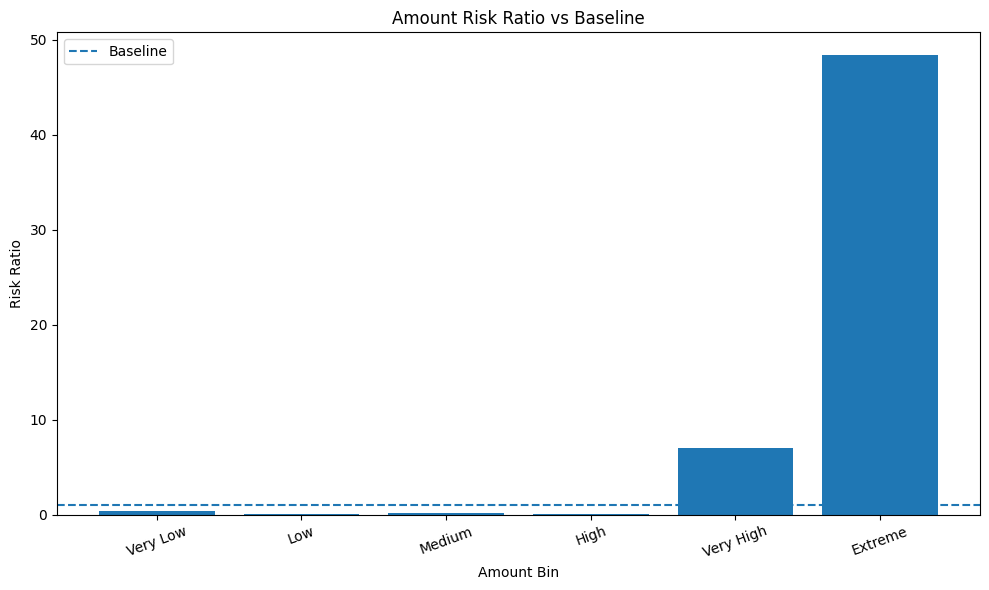

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    amount_summary.index,
    amount_summary["risk_ratio"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Amount Bin")
plt.ylabel("Risk Ratio")
plt.title("Amount Risk Ratio vs Baseline")

plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def compute_amount_bins_v2(
    df,
    amt_col="amt",
    target_col="is_fraud",
    baseline_rate=None
):

    bins = [
        0,
        47.50,
        196.07,
        548.6261,
        np.inf
    ]

    labels = [
        "Very Low",
        "Normal",
        "Very High",
        "Extreme"
    ]

    df = df.copy()

    df["amount_bin"] = pd.cut(
        df[amt_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    summary = df.groupby(
        "amount_bin",
        observed=True
    ).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )

    summary["fraud_rate"] = (
        summary["fraud_count"] /
        summary["count"]
    )

    summary["risk_ratio"] = (
        summary["fraud_rate"] /
        baseline_rate
    )

    return summary


amount_summary_v2 = compute_amount_bins_v2(
   train_df,
    baseline_rate=baseline_rate
)

display(amount_summary_v2)

,count,fraud_count,fraud_rate,risk_ratio
amount_bin,,,,
Very Low,648228,1565,0.002414,0.417070
Normal,583415,236,0.000405,0.069881
Very High,52169,2105,0.040350,6.970472
Extreme,12863,3600,0.279873,48.348478


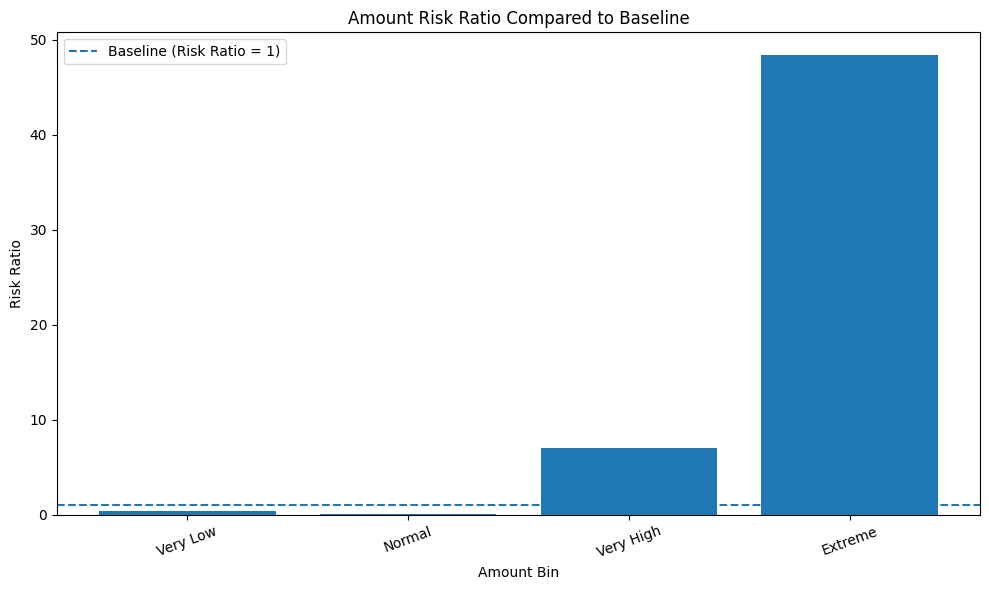

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    amount_summary_v2.index,
    amount_summary_v2["risk_ratio"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline (Risk Ratio = 1)"
)

plt.xlabel("Amount Bin")
plt.ylabel("Risk Ratio")
plt.title("Amount Risk Ratio Compared to Baseline")

plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

Baseline Fraud Rate
                  (0.5789%  →  risk_ratio = 1.0)
                            |
                            |
        ┌───────────────────┴───────────────────┐
        |                                        |
  Lower Risk Zone                         Higher Risk Zone
   (risk_ratio < 1)                        (risk_ratio > 1)
        |                                        |
   ┌────┴────┐                            ┌───────┴───────┐
   |         |                            |               |
 Normal   Very Low                    Very High         Extreme
 ratio=   ratio=                      ratio=             ratio=
  0.07     0.42                        6.96              48.12


Time Risk

In [ ]:
# ==========================================
# 1. Time Feature Engineering
# ==========================================

train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

train_df["trans_hour"] = (
    train_df["trans_date_trans_time"].dt.hour
)

train_df["trans_day"] = (
    train_df["trans_date_trans_time"].dt.day
)

train_df["trans_month"] = (
    train_df["trans_date_trans_time"].dt.month
)

train_df["trans_dayofweek"] = (
    train_df["trans_date_trans_time"].dt.dayofweek
)



In [ ]:
def compute_hour_summary(df, hour_col="trans_hour", target_col="is_fraud", baseline_rate=None):
    summary = df.groupby(hour_col, observed=True).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )
    summary["fraud_rate"] = summary["fraud_count"] / summary["count"]
    summary["risk_ratio"] = summary["fraud_rate"] / baseline_rate
    summary = summary.sort_index()

    return summary

hour_summary = compute_hour_summary(train_df, baseline_rate=baseline_rate)
display(hour_summary)

,count,fraud_count,fraud_rate,risk_ratio
trans_hour,,,,
0,42502,635,0.014940,2.580994
1,42869,658,0.015349,2.651582
2,42656,625,0.014652,2.531177
3,42769,609,0.014239,2.459862
4,41863,46,0.001099,0.189824
5,42171,60,0.001423,0.245788
6,42300,40,0.000946,0.163359
7,42203,56,0.001327,0.229228
8,42505,49,0.001153,0.199149


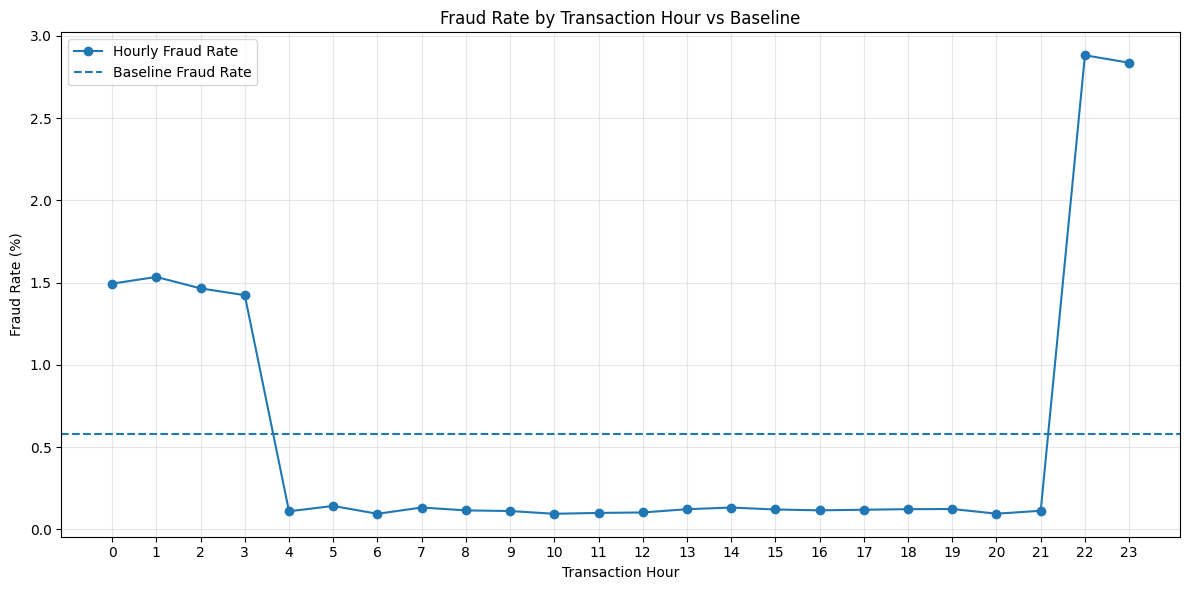

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    hour_summary.index,
    hour_summary["fraud_rate"] * 100,
    marker="o",
    label="Hourly Fraud Rate"
)

plt.axhline(
    y=baseline_rate * 100,
    linestyle="--",
    label="Baseline Fraud Rate"
)

plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Hour vs Baseline")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def compute_time_bins(df, hour_col="trans_hour", target_col="is_fraud", baseline_rate=None):
    def map_hour_to_bin(hour):
        if hour in [22, 23]:
            return "Peak Risk"
        elif hour in [0, 1, 2, 3]:
            return "High Risk"
        else:
            return "Normal"

    df = df.copy()
    df["time_bin"] = df[hour_col].apply(map_hour_to_bin)

    summary = df.groupby("time_bin", observed=True).agg(
        count=(target_col, "size"),
        fraud_count=(target_col, "sum")
    )
    summary["fraud_rate"] = summary["fraud_count"] / summary["count"]
    summary["risk_ratio"] = summary["fraud_rate"] / baseline_rate

    return summary

time_summary = compute_time_bins(train_df, baseline_rate=baseline_rate)
display(time_summary)

,count,fraud_count,fraud_rate,risk_ratio
time_bin,,,,
High Risk,170796,2527,0.014795,2.555937
Normal,991793,1144,0.001153,0.199263
Peak Risk,134086,3835,0.028601,4.940882


category_name

In [ ]:
RISK_CATEGORICAL_COLS = [
    "category",
    "merchant",
    "job"
]

In [37]:
RISK_CATEGORICAL_COLS = [
    "category",
    "merchant",
    "job"
]

In [56]:
import pandas as pd


class AFRIPRiskPipeline:

    def __init__(self):

        self.amount_bins = [0, 47.50, 196.07, 548.6261, None]
        self.amount_labels = ["Very Low", "Normal", "Very High", "Extreme"]
        self.amount_risk_ratio = {
            "Very Low": 0.42,
            "Normal": 0.07,
            "Very High": 6.96,
            "Extreme": 48.12
        }

        self.hour_to_bin = {
            0: "High Risk", 1: "High Risk", 2: "High Risk", 3: "High Risk",
            4: "Normal", 5: "Normal", 6: "Normal", 7: "Normal",
            8: "Normal", 9: "Normal", 10: "Normal", 11: "Normal",
            12: "Normal", 13: "Normal", 14: "Normal", 15: "Normal",
            16: "Normal", 17: "Normal", 18: "Normal", 19: "Normal",
            20: "Normal", 21: "Normal",
            22: "Peak Risk", 23: "Peak Risk"
        }
        self.time_risk_ratio = {
            "Normal": 0.199263,
            "High Risk": 2.555937,
            "Peak Risk": 4.940882
        }

        self.baseline_fraud_rate = 0.005789


    def _get_amount_risk(self, amt):

        bins = self.amount_bins
        labels = self.amount_labels

        for i in range(len(labels)):
            lower = bins[i]
            upper = bins[i + 1]

            if upper is None:
                if amt > lower:
                    level = labels[i]
                    break
            else:
                if lower < amt <= upper:
                    level = labels[i]
                    break

        return {
            "value": amt,
            "level": level,
            "risk_ratio": self.amount_risk_ratio[level]
        }


    def _get_time_risk(self, trans_date_trans_time):

        try:
            parsed_time = pd.to_datetime(trans_date_trans_time)
        except Exception:
            return {
                "value": trans_date_trans_time,
                "level": "Invalid",
                "risk_ratio": None,
                "error": "Could not parse trans_date_trans_time"
            }

        hour = parsed_time.hour
        level = self.hour_to_bin[hour]

        return {
            "value": hour,
            "level": level,
            "risk_ratio": self.time_risk_ratio[level]
        }


    def predict(self, raw_data):

        amt = raw_data["amt"]
        trans_date_trans_time = raw_data["trans_date_trans_time"]

        amount_result = self._get_amount_risk(amt)
        time_result = self._get_time_risk(trans_date_trans_time)

        return {
            "amount_risk": amount_result,
            "time_risk": time_result
        }

In [57]:
risk_pipeline = AFRIPRiskPipeline()

In [58]:
import pickle

risk_pipeline = AFRIPRiskPipeline()

with open(r"M:\NT_PROJECT\afrip_risk_pipeline.pkl", "wb") as f:
    pickle.dump(risk_pipeline, f)

print("Saved to M:\\NT_PROJECT\\afrip_risk_pipeline.pkl")

Saved to M:\NT_PROJECT\afrip_risk_pipeline.pkl


In [59]:
raw_data = {
    "amt": 350.75,
    "category": "shopping_net",
    "merchant": "merchant_example",
    "gender": "M",
    "job": "Software Engineer",
    "state": "NY",
    "trans_date_trans_time": "2026-08-12 14:30:00",
    "dob": "1998-05-20"
}

result = risk_pipeline.predict(raw_data)
print(result)

{'amount_risk': {'value': 350.75, 'level': 'Very High', 'risk_ratio': 6.96}, 'time_risk': {'value': 14, 'level': 'Normal', 'risk_ratio': 0.199263}}


In [60]:
def display_risk_result(result):

    rows = []

    for risk_type, details in result.items():

        rows.append({
            "Risk Type": risk_type,
            "Value": details.get("value"),
            "Level": details.get("level"),
            "Risk Ratio": details.get("risk_ratio")
        })

    return pd.DataFrame(rows)


result = risk_pipeline.predict(raw_data)

result_df = display_risk_result(result)
display(result_df)

,Risk Type,Value,Level,Risk Ratio
0,amount_risk,350.75,Very High,6.960000
1,time_risk,14.00,Normal,0.199263
